**1. Install Dependencies**

In [ ]:
!pip install torch
!pip install pandas
!pip install nltk
!pip install bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import torch
import pandas as pd
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'train_en_10000.csv', 'test_en_1000.csv', 'train_sa_10000.csv', 'dev_sa_1000.csv', 'dev_en_1000.csv', 'test_sa_1000.csv', 'sample_data']


**3. Configuration**
 configurable parameters used throughout the project.

Project: Sanskrit → English Neural Machine Translation


In [ ]:
import os
import torch

# =========================================================
# Project Directories
# =========================================================

# Root directory of the project
PROJECT_ROOT = "/content"
print(PROJECT_ROOT)
# Data directories
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")

# Output directories
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")


# =========================================================
# Dataset Paths
# =========================================================

TRAIN_SA_PATH = os.path.join(PROJECT_ROOT, "train_sa_10000.csv")
TRAIN_EN_PATH = os.path.join(PROJECT_ROOT, "train_en_10000.csv")

DEV_SA_PATH = os.path.join(PROJECT_ROOT, "dev_sa_1000.csv")
DEV_EN_PATH = os.path.join(PROJECT_ROOT, "dev_en_1000.csv")

TEST_SA_PATH = os.path.join(PROJECT_ROOT, "test_sa_1000.csv")
TEST_EN_PATH = os.path.join(PROJECT_ROOT, "test_en_1000.csv")

# -----------------------------
# Dataset Column Names
# -----------------------------
SOURCE_ID_COL = "Source_id"
SANSKRIT_COL = "Sentence_sa"
ENGLISH_COL = "Sentence_en"
# =========================================================
# Special Tokens
# =========================================================

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"


# =========================================================
# Model Hyperparameters
# =========================================================

EMBEDDING_DIM = 300
HIDDEN_DIM = 512
NUM_LAYERS = 1
DROPOUT = 0.5
EMBEDDING_DIM = 256
BIDIRECTIONAL = True
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
GRAD_CLIP = 1.0


# =========================================================
# Training Hyperparameters
# =========================================================

BATCH_SIZE = 64
LEARNING_RATE = 0.001

# =========================================================
# Checkpoints
# =========================================================

CHECKPOINT_DIR = "checkpoints"

BEST_MODEL = "best_model.pt"

# =========================================================
# Device Configuration
# =========================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/content


**4. Dataset**

Dataset Module
---------------------------------------------------------
This module defines the PyTorch Dataset class for the
Sanskrit → English Neural Machine Translation project.

Responsibilities:
1. Read Sanskrit and English CSV files.
2. Validate dataset columns.
3. Merge the datasets using Source ID.
4. Return parallel sentence pairs.

In [ ]:

import pandas as pd
from torch.utils.data import Dataset



class SanskritTranslationDataset(Dataset):
    """
    PyTorch Dataset for Sanskrit-English Translation.

    Each sample contains:
        - Source ID
        - Sanskrit sentence
        - English sentence
    """

    def __init__(self, sa_path, en_path):
        """
        Initialize the dataset.

        Parameters
        ----------
        sa_path : str
            Path to Sanskrit CSV.

        en_path : str
            Path to English CSV.
        """

        # -------------------------------------------------
        # Read CSV files
        # -------------------------------------------------
        self.sa_df = pd.read_csv(sa_path)
        self.en_df = pd.read_csv(en_path)

        # -------------------------------------------------
        # Remove unwanted spaces from column names
        # -------------------------------------------------
        self.sa_df.columns = self.sa_df.columns.str.strip()
        self.en_df.columns = self.en_df.columns.str.strip()

        # -------------------------------------------------
        # Validate required columns
        # -------------------------------------------------
        required_sa = {SOURCE_ID_COL, SANSKRIT_COL}
        required_en = {SOURCE_ID_COL, ENGLISH_COL}

        if not required_sa.issubset(self.sa_df.columns):
            raise ValueError(
                f"Sanskrit CSV missing columns.\n"
                f"Expected : {required_sa}\n"
                f"Found    : {list(self.sa_df.columns)}"
            )

        if not required_en.issubset(self.en_df.columns):
            raise ValueError(
                f"English CSV missing columns.\n"
                f"Expected : {required_en}\n"
                f"Found    : {list(self.en_df.columns)}"
            )

        # -------------------------------------------------
        # Merge Sanskrit and English datasets
        # -------------------------------------------------
        self.data = pd.merge(
            self.sa_df,
            self.en_df,
            on=SOURCE_ID_COL,
            how="inner"
        )

        # -------------------------------------------------
        # Reset DataFrame index
        # -------------------------------------------------
        self.data.reset_index(drop=True, inplace=True)

        print("=" * 60)
        print("Dataset Loaded Successfully")
        print(f"Total Sentence Pairs : {len(self.data)}")
        print("=" * 60)

    def __len__(self):
        """
        Returns the total number of sentence pairs.
        """
        return len(self.data)

    def __getitem__(self, index):
        """
        Returns one Sanskrit-English sentence pair.

        Parameters
        ----------
        index : int

        Returns
        -------
        dict
        """

        row = self.data.iloc[index]

        sample = {
            "source_id": row[SOURCE_ID_COL],
            "sanskrit": row[SANSKRIT_COL],
            "english": row[ENGLISH_COL]
        }

        return sample

    def show_sample(self, index=0):
        """
        Display a sample from the dataset.
        """

        sample = self[index]

        print("=" * 60)
        print(f"Source ID : {sample['source_id']}")
        print(f"Sanskrit : {sample['sanskrit']}")
        print(f"English  : {sample['english']}")
        print("=" * 60)

    def dataset_info(self):
        """
        Display dataset information.
        """

        print("\n========== Dataset Information ==========")
        print(f"Total Samples : {len(self)}")
        print(f"Columns       : {list(self.data.columns)}")
        print("\nMissing Values")
        print(self.data.isnull().sum())

        print("\nDuplicate Rows :", self.data.duplicated().sum())
        print("=========================================\n")

Collate Module

Creates mini-batches for the DataLoader.

Pipeline

Batch ,Preprocess,Tokenize,Vocabulary,Padding,Tensor


In [ ]:

import torch
from torch.nn.utils.rnn import pad_sequence



class CollateFn:
    """
    Custom collate function for DataLoader.
    """

    def __init__(
        self,
        preprocessor,
        tokenizer,
        src_vocab,
        tgt_vocab
    ):

        self.preprocessor = preprocessor
        self.tokenizer = tokenizer

        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

        self.src_pad_idx = src_vocab.word2idx[PAD_TOKEN]
        self.tgt_pad_idx = tgt_vocab.word2idx[PAD_TOKEN]

    def __call__(self, batch):
        """
        Parameters
        ----------
        batch : list

            List of samples from Dataset

        Returns
        -------
        dict
        """

        source_ids = []

        src_sequences = []
        tgt_sequences = []

        for sample in batch:

            # -----------------------------------------
            # Source ID
            # -----------------------------------------
            source_ids.append(sample["source_id"])

            # -----------------------------------------
            # Sanskrit
            # -----------------------------------------
            src_sentence = self.preprocessor.preprocess_sanskrit(
                sample["sanskrit"]
            )

            src_tokens = self.tokenizer.tokenize_sanskrit(
                src_sentence
            )

            src_ids = self.src_vocab.numericalize(
                src_tokens
            )

            src_sequences.append(
                torch.tensor(
                    src_ids,
                    dtype=torch.long
                )
            )

            # -----------------------------------------
            # English
            # -----------------------------------------
            tgt_sentence = self.preprocessor.preprocess_english(
                sample["english"]
            )

            tgt_tokens = self.tokenizer.tokenize_english(
                tgt_sentence
            )

            tgt_ids = self.tgt_vocab.numericalize(
                tgt_tokens
            )

            tgt_sequences.append(
                torch.tensor(
                    tgt_ids,
                    dtype=torch.long
                )
            )

        # ---------------------------------------------
        # Padding
        # ---------------------------------------------

        src_batch = pad_sequence(
            src_sequences,
            batch_first=True,
            padding_value=self.src_pad_idx
        )

        tgt_batch = pad_sequence(
            tgt_sequences,
            batch_first=True,
            padding_value=self.tgt_pad_idx
        )

        return {

            "source_id": source_ids,

            "src": src_batch,

            "tgt": tgt_batch

        }

**5. Preprocessing**
Preprocessing Module
---------------------------------------------------------
This module performs basic text preprocessing for the
Sanskrit → English Neural Machine Translation project.

Responsibilities:
1. Normalize Unicode text.
2. Remove extra whitespace.
3. Remove tabs/newlines.
4. Prepare clean text for tokenization.


In [ ]:
import re
import unicodedata


class Preprocessor:
    """
    Basic text preprocessor.
    """

    def __init__(self):
        pass

    # =====================================================
    # Common Cleaning
    # =====================================================

    def clean_text(self, sentence: str) -> str:
        """
        Perform common preprocessing steps.

        Parameters
        ----------
        sentence : str

        Returns
        -------
        str
        """

        if not isinstance(sentence, str):
            raise TypeError("Input must be a string.")

        # Unicode normalization
        sentence = unicodedata.normalize("NFC", sentence)

        # Remove tabs/newlines
        sentence = sentence.replace("\n", " ")
        sentence = sentence.replace("\t", " ")

        # Replace multiple spaces with single space
        sentence = re.sub(r"\s+", " ", sentence)

        # Remove leading/trailing spaces
        sentence = sentence.strip()

        return sentence

    # =====================================================
    # Sanskrit
    # =====================================================

    def preprocess_sanskrit(self, sentence: str) -> str:
        """
        Preprocess Sanskrit sentence.
        """

        sentence = self.clean_text(sentence)

        return sentence

    # =====================================================
    # English
    # =====================================================

    def preprocess_english(self, sentence: str) -> str:
        """
        Preprocess English sentence.
        """

        sentence = self.clean_text(sentence)

        return sentence

    # =====================================================
    # Generic
    # =====================================================

    def preprocess(self, sentence: str, language="sa") -> str:
        """
        Generic preprocessing interface.

        Parameters
        ----------
        sentence : str

        language : str
            "sa" -> Sanskrit
            "en" -> English
        """

        if language == "sa":
            return self.preprocess_sanskrit(sentence)

        elif language == "en":
            return self.preprocess_english(sentence)

        else:
            raise ValueError("Language must be 'sa' or 'en'")


Tokenizer Module
---------------------------------------------------------
Tokenizer for Sanskrit → English Neural Machine Translation

Sanskrit:
    - Space-based tokenization
    - Handles Devanagari danda (।)

English:
    - Word-level tokenization
    - Separates punctuation


In [ ]:

import re


class Tokenizer:

    def __init__(self):
        pass

    # =====================================================
    # Sanskrit Tokenizer
    # =====================================================

    def tokenize_sanskrit(self, sentence: str):
        """
        Tokenize Sanskrit sentence.

        Example
        -------
        Input:
            रामः वनं गच्छति।

        Output:
            ['रामः', 'वनं', 'गच्छति', '।']
        """

        if not isinstance(sentence, str):
            raise TypeError("Sentence must be a string.")

        sentence = sentence.strip()

        # Separate Sanskrit danda
        sentence = sentence.replace("।", " ।")

        # Remove extra spaces
        sentence = re.sub(r"\s+", " ", sentence)

        tokens = sentence.split(" ")

        return tokens

    # =====================================================
    # English Tokenizer
    # =====================================================

    def tokenize_english(self, sentence: str):
        """
        Tokenize English sentence.

        Example
        -------
        Input:
            Rama goes to the forest.

        Output:
            ['Rama','goes','to','the','forest','.']
        """

        if not isinstance(sentence, str):
            raise TypeError("Sentence must be a string.")

        sentence = sentence.strip()

        tokens = re.findall(
            r"[A-Za-z]+(?:'[A-Za-z]+)?|[.,!?;:]",
            sentence
        )

        return tokens

    # =====================================================
    # Generic Tokenizer
    # =====================================================

    def tokenize(self, sentence: str, language="sa"):

        if language.lower() == "sa":
            return self.tokenize_sanskrit(sentence)

        elif language.lower() == "en":
            return self.tokenize_english(sentence)

        else:
            raise ValueError(
                "language must be 'sa' or 'en'"
            )

    # =====================================================
    # Sanskrit Detokenizer
    # =====================================================

    def detokenize_sanskrit(self, tokens):

        sentence = " ".join(tokens)

        sentence = sentence.replace(" ।", "।")

        return sentence

    # =====================================================
    # English Detokenizer
    # =====================================================

    def detokenize_english(self, tokens):

        sentence = " ".join(tokens)

        sentence = re.sub(
            r"\s+([.,!?;:])",
            r"\1",
            sentence
        )

        return sentence

    # =====================================================
    # Generic Detokenizer
    # =====================================================

    def detokenize(self, tokens, language="sa"):

        if language.lower() == "sa":
            return self.detokenize_sanskrit(tokens)

        elif language.lower() == "en":
            return self.detokenize_english(tokens)

        else:
            raise ValueError(
                "language must be 'sa' or 'en'"
            )


Vocabulary Module
---------------------------------------------------------
Vocabulary class for Sanskrit-English Neural Machine
Translation (NMT).

Responsibilities
----------------
1. Build vocabulary from tokenized sentences.
2. Convert words <-> integer IDs.
3. Handle special tokens.
4. Save and load vocabulary.


In [ ]:
import pickle
from collections import Counter




class Vocabulary:
    """
    Vocabulary class for one language.

    Example:
        src_vocab = Vocabulary()
        tgt_vocab = Vocabulary()
    """

    def __init__(self, min_freq=1):

        self.min_freq = min_freq

        # Word -> Index
        self.word2idx = {}

        # Index -> Word
        self.idx2word = {}

        # Word Frequency
        self.word_freq = Counter()

        # Initialize special tokens
        self._initialize_special_tokens()

    # =====================================================
    # Initialize Special Tokens
    # =====================================================

    def _initialize_special_tokens(self):

        special_tokens = [
            PAD_TOKEN,
            SOS_TOKEN,
            EOS_TOKEN,
            UNK_TOKEN
        ]

        for idx, token in enumerate(special_tokens):
            self.word2idx[token] = idx
            self.idx2word[idx] = token

    # =====================================================
    # Build Vocabulary
    # =====================================================

    def build_vocab(self, tokenized_sentences):
        """
        Build vocabulary from tokenized sentences.
        """

        # Count word frequencies
        for sentence in tokenized_sentences:
            self.word_freq.update(sentence)

        # Add words satisfying minimum frequency
        for word, freq in self.word_freq.items():

            if freq >= self.min_freq:

                if word not in self.word2idx:

                    idx = len(self.word2idx)

                    self.word2idx[word] = idx
                    self.idx2word[idx] = word

        print("=" * 60)
        print("Vocabulary Built Successfully")
        print(f"Vocabulary Size : {self.vocab_size}")
        print("=" * 60)

    # =====================================================
    # Word -> ID
    # =====================================================

    def lookup_word(self, word):

        return self.word2idx.get(
            word,
            self.word2idx[UNK_TOKEN]
        )

    # =====================================================
    # ID -> Word
    # =====================================================

    def lookup_index(self, index):

        return self.idx2word.get(
            index,
            UNK_TOKEN
        )

    # =====================================================
    # Sentence -> IDs
    # =====================================================

    def numericalize(self, tokens):
        """
        Convert tokens to integer IDs.
        """

        ids = [self.word2idx[SOS_TOKEN]]

        for token in tokens:
            ids.append(self.lookup_word(token))

        ids.append(self.word2idx[EOS_TOKEN])

        return ids

    # =====================================================
    # IDs -> Tokens
    # =====================================================

    def denumericalize(self, ids):
        """
        Convert integer IDs back to tokens.
        """

        tokens = []

        for idx in ids:

            token = self.lookup_index(idx)

            if token in (
                PAD_TOKEN,
                SOS_TOKEN,
                EOS_TOKEN
            ):
                continue

            tokens.append(token)

        return tokens

    # =====================================================
    # Vocabulary Size
    # =====================================================

    @property
    def vocab_size(self):

        return len(self.word2idx)

    # =====================================================
    # Length
    # =====================================================

    def __len__(self):

        return self.vocab_size

    # =====================================================
    # Contains
    # =====================================================

    def __contains__(self, word):

        return word in self.word2idx

    # =====================================================
    # Show Vocabulary
    # =====================================================

    def show_vocab(self, n=20):

        print("=" * 60)

        for i, (word, idx) in enumerate(self.word2idx.items()):

            print(f"{idx:4d} : {word}")

            if i + 1 >= n:
                break

        print("=" * 60)

    # =====================================================
    # Save Vocabulary
    # =====================================================

    def save(self, filepath):

        with open(filepath, "wb") as f:
            pickle.dump(self, f)

        print(f"Vocabulary saved to {filepath}")

    # =====================================================
    # Load Vocabulary
    # =====================================================

    @staticmethod
    def load(filepath):

        with open(filepath, "rb") as f:
            vocab = pickle.load(f)

        print(f"Vocabulary loaded from {filepath}")

        return vocab

**Models**


**Bahdanau Attention**

In [ ]:


import torch
import torch.nn as nn


class BahdanauAttention(nn.Module):

    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):

        super().__init__()

        #  encoder outputs
        self.encoder_projection = nn.Linear(
            encoder_hidden_dim,
            decoder_hidden_dim
        )

        #  decoder hidden state
        self.decoder_projection = nn.Linear(
            decoder_hidden_dim,
            decoder_hidden_dim
        )

        # Compute attention score
        self.energy = nn.Linear(
            decoder_hidden_dim,
            1
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs
    ):
        """
        Parameters
        ----------
        decoder_hidden
            (batch, decoder_hidden)

        encoder_outputs
            (batch, seq_len, encoder_hidden)
        """

        batch_size = encoder_outputs.size(0)
        seq_len = encoder_outputs.size(1)

        # Expand decoder hidden across sequence length
        decoder_hidden = decoder_hidden.unsqueeze(1)

        decoder_hidden = decoder_hidden.repeat(
            1,
            seq_len,
            1
        )

        # Compute energy
        energy = torch.tanh(

            self.encoder_projection(encoder_outputs)

            +

            self.decoder_projection(decoder_hidden)

        )

        # Compute scores
        scores = self.energy(energy).squeeze(-1)

        # Normalize
        attention_weights = torch.softmax(
            scores,
            dim=1)



        # Context vector
        context = torch.bmm(

            attention_weights.unsqueeze(1),

            encoder_outputs

        )

        context = context.squeeze(1)

        return context, attention_weights

Encoder Module

Bidirectional LSTM Encoder
for Sanskrit → English Neural Machine Translation

Input
-----
(batch_size, sequence_length)

Output
------
Encoder Outputs
Hidden State
Cell State


In [ ]:

import torch
import torch.nn as nn




class Encoder(nn.Module):
    """
    Bidirectional LSTM Encoder.
    """

    def __init__(
        self,
        input_dim,
        embedding_dim,
        hidden_dim,
        num_layers,
        dropout,
        bidirectional=True,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # -----------------------------------------
        # Embedding Layer
        # -----------------------------------------
        self.embedding = nn.Embedding(
            num_embeddings=input_dim,
            embedding_dim=embedding_dim,
            padding_idx=0,
        )

        # -----------------------------------------
        # Dropout
        # -----------------------------------------
        self.dropout = nn.Dropout(dropout)

        # -----------------------------------------
        # BiLSTM
        # -----------------------------------------
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
            batch_first=True,
        )
        # -----------------------------------------
        # Bridge Layers
        # -----------------------------------------

        bridge_input_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.hidden_bridge = nn.Linear(
              bridge_input_dim,
              hidden_dim
        )

        self.cell_bridge = nn.Linear(
              bridge_input_dim,
              hidden_dim
          )

    def forward(self, src):
        """
        Parameters
        ----------
        src

        Shape:
            (batch_size, sequence_length)
        """

        # -----------------------------------------
        # Embedding
        # -----------------------------------------
        embedded = self.embedding(src)

        embedded = self.dropout(embedded)

        # -----------------------------------------
        # LSTM
        # -----------------------------------------
        outputs, (hidden, cell) = self.lstm(embedded)

        # -----------------------------------------
        # Bridge Bidirectional States
        # -----------------------------------------

        if self.bidirectional:

            # hidden:
            # (2, batch, hidden)

          hidden = torch.cat(
              (hidden[-2], hidden[-1]),
              dim=1
          )

          hidden = torch.relu(
              self.hidden_bridge(hidden)
          )

          hidden = hidden.unsqueeze(0)

    # -------------------------------------

          cell = torch.cat(
              (cell[-2], cell[-1]),
              dim=1
          )

          cell = torch.relu(
              self.cell_bridge(cell)
          )

          cell = cell.unsqueeze(0)

          return outputs, hidden, cell




Decoder Module

LSTM Decoder with Bahdanau Attention



In [ ]:

import torch
import torch.nn as nn


class Decoder(nn.Module):
    """
    LSTM Decoder with Bahdanau Attention
    """

    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        num_layers,
        dropout,
        attention
    ):
        super().__init__()

        self.output_dim = output_dim
        self.decoder_hidden_dim = decoder_hidden_dim
        self.attention = attention

        # -------------------------------------------------
        # Target Embedding
        # -------------------------------------------------

        self.embedding = nn.Embedding(
            num_embeddings=output_dim,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.dropout = nn.Dropout(dropout)

        # -------------------------------------------------
        # LSTM
        #
        # Input =
        # Embedding + Context Vector
        # -------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=embedding_dim + encoder_hidden_dim,
            hidden_size=decoder_hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # -------------------------------------------------
        # Vocabulary Prediction
        # -------------------------------------------------

        self.fc = nn.Linear(
          decoder_hidden_dim +
          encoder_hidden_dim +
          embedding_dim,
          output_dim
          )

    def forward(
        self,
        input_token,
        hidden,
        cell,
        encoder_outputs
    ):
        """
        Parameters
        ----------
        input_token : Tensor
            Shape = (batch)

        hidden : Tensor
            Shape = (num_layers, batch, decoder_hidden_dim)

        cell : Tensor
            Shape = (num_layers, batch, decoder_hidden_dim)

        encoder_outputs : Tensor
            Shape = (batch, src_len, encoder_hidden_dim)

        Returns
        -------
        prediction : Tensor
            Shape = (batch, output_dim)

        hidden : Tensor

        cell : Tensor

        attention_weights : Tensor
            Shape = (batch, src_len)
        """

        # -------------------------------------------------
        # Embedding
        # -------------------------------------------------

        embedded = self.embedding(input_token)

        # (batch, embedding_dim)

        embedded = self.dropout(embedded)

        # -------------------------------------------------
        # Attention
        # -------------------------------------------------

        context, attention_weights = self.attention(

            hidden[-1],

            encoder_outputs

        )

        # context
        # (batch, encoder_hidden_dim)

        # -------------------------------------------------
        # Prepare LSTM Input
        # -------------------------------------------------

        lstm_input = torch.cat(

            (

                embedded,

                context

            ),

            dim=1

        )

        # (batch, embedding_dim + encoder_hidden_dim)

        lstm_input = lstm_input.unsqueeze(1)

        # (batch, 1, embedding_dim + encoder_hidden_dim)

        # -------------------------------------------------
        # Decoder LSTM
        # -------------------------------------------------

        output, (hidden, cell) = self.lstm(

            lstm_input,

            (hidden, cell)

        )

        # output
        # (batch,1,decoder_hidden_dim)

        # -------------------------------------------------
        # Vocabulary Prediction
        # -------------------------------------------------

        combined = torch.cat(
            (
                output.squeeze(1),
                context,
                embedded
            ),
            dim=1
        )

        combined = self.dropout(combined)

        prediction = self.fc(combined)





        # (batch, output_dim)

        return (

            prediction,

            hidden,

            cell,

            attention_weights

        )


Seq2Seq Model

Sanskrit -> English Neural Machine Translation

Architecture
------------
Source Sentence -- Encoder (BiLSTM) -- Bridge Layer --
Bahdanau Attention Decoder (LSTM)
--- Vocabulary Prediction


In [ ]:


import random
import torch
import torch.nn as nn


class Seq2Seq(nn.Module):
    """
    Complete Seq2Seq Model
    """

    def __init__(
        self,
        encoder,
        decoder,
        device
    ):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    # =====================================================
    # Forward Pass
    # =====================================================

    def forward(
        self,
        src,
        tgt,
        teacher_forcing_ratio=0.5
    ):
        """
        Parameters
        ----------
        src
            Source sentence
            Shape:
                (batch_size, src_len)

        tgt
            Target sentence
            Shape:
                (batch_size, tgt_len)

        teacher_forcing_ratio
            Probability of using ground-truth token.

        Returns
        -------
        outputs
            Shape:
                (batch_size,
                 tgt_len,
                 target_vocab_size)
        """

        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        vocab_size = self.decoder.output_dim

        # Store decoder predictions
        outputs = torch.zeros(
            batch_size,
            tgt_len,
            vocab_size,
            device=self.device
        )

        # Encoder
        encoder_outputs, hidden, cell = self.encoder(src)

        # First decoder input = <SOS>
        input_token = tgt[:, 0]

        # Decoder loop
        for t in range(1, tgt_len):

            prediction, hidden, cell, attention_weights = self.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs
            )

            outputs[:, t, :] = prediction

            top1 = prediction.argmax(dim=1)

            teacher_force = random.random() < teacher_forcing_ratio

            input_token = tgt[:, t] if teacher_force else top1

        return outputs

    # =====================================================
    # Greedy Translation
    # =====================================================

    def translate(
        self,
        src,
        sos_idx,
        eos_idx,
        max_length=50
    ):
        """
        Greedy decoding for inference.
        """

        self.eval()

        with torch.no_grad():

            # Encoder
            encoder_outputs, hidden, cell = self.encoder(src)

            # First decoder input = <SOS>
            input_token = torch.tensor(
                [sos_idx],
                device=self.device
            )

            outputs = []

            for _ in range(max_length):

                prediction, hidden, cell, _ = self.decoder(
                    input_token,
                    hidden,
                    cell,
                    encoder_outputs
                )

                predicted_token = prediction.argmax(dim=1)
                token = predicted_token.item()

                if token == eos_idx:
                    break

                outputs.append(token)

                input_token = predicted_token

        return outputs

    # =====================================================
    # Beam Search Translation
    # =====================================================

    def beam_search(
        self,
        src,
        sos_idx,
        eos_idx,
        beam_width=5,
        max_length=50
    ):
        """
        Beam Search decoding for inference.
        Works with batch size = 1.
        """

        self.eval()

        with torch.no_grad():

            # -----------------------------------------
            # Encoder
            # -----------------------------------------

            encoder_outputs, hidden, cell = self.encoder(src)

            beams = [
                (
                    [sos_idx],
                    0.0,
                    hidden,
                    cell
                )
            ]

            completed = []

            # -----------------------------------------
            # Decoder
            # -----------------------------------------

            for _ in range(max_length):

                candidates = []

                for seq, score, hidden_state, cell_state in beams:

                    last_token = seq[-1]

                    if last_token == eos_idx:

                        completed.append(
                            (seq, score)
                        )

                        continue

                    input_token = torch.tensor(
                        [last_token],
                        dtype=torch.long,
                        device=self.device
                    )

                    prediction, next_hidden, next_cell, _ = self.decoder(
                        input_token,
                        hidden_state,
                        cell_state,
                        encoder_outputs
                    )

                    log_probs = torch.log_softmax(
                        prediction,
                        dim=1
                    )

                    top_scores, top_indices = torch.topk(
                        log_probs,
                        beam_width,
                        dim=1
                    )

                    for k in range(beam_width):

                        token = top_indices[0, k].item()

                        token_score = top_scores[0, k].item()

                        candidates.append(
                            (
                                seq + [token],
                                score + token_score,
                                next_hidden,
                                next_cell
                            )
                        )

                if len(candidates) == 0:
                    break

                candidates = sorted(
                    candidates,
                    key=lambda x: x[1],
                    reverse=True
                )

                beams = candidates[:beam_width]

            # -----------------------------------------
            # Best Sequence
            # -----------------------------------------

            if len(completed) > 0:

                completed = sorted(
                    completed,
                    key=lambda x: x[1],
                    reverse=True
                )

                best_sequence = completed[0][0]

            else:

                best_sequence = beams[0][0]

            # Remove SOS

            best_sequence = best_sequence[1:]

            # Remove EOS

            if eos_idx in best_sequence:

                eos_position = best_sequence.index(eos_idx)

                best_sequence = best_sequence[:eos_position]

            return best_sequence


metrics

Evaluation Metrics for Sanskrit → English NMT

Provides:
1. BLEU Score
2. BERTScore
3. Token Accuracy
4. Parameter Count
5. Inference Time


In [ ]:


import time
import torch

from nltk.translate.bleu_score import (
    corpus_bleu,
    SmoothingFunction
)

from bert_score import score


# ==========================================================
# BLEU Score
# ==========================================================

def calculate_bleu(references, hypotheses):
    """
    Calculate Corpus BLEU Score.

    Parameters
    ----------
    references : List[List[List[str]]]
    hypotheses : List[List[str]]

    Returns
    -------
    float
    """

    smoothie = SmoothingFunction().method4

    bleu = corpus_bleu(
        references,
        hypotheses,
        smoothing_function=smoothie
    )

    return bleu


# ==========================================================
# BERTScore
# ==========================================================

def calculate_bertscore(
    references,
    hypotheses,
    lang="en"
):
    """
    Calculate BERTScore.

    Returns
    -------
    precision, recall, f1
    """

    P, R, F1 = score(
        hypotheses,
        references,
        lang=lang,
        verbose=False
    )

    return (
        P.mean().item(),
        R.mean().item(),
        F1.mean().item()
    )


# ==========================================================
# Token Accuracy
# ==========================================================

def calculate_accuracy(
    predictions,
    targets,
    pad_idx=0
):
    """
    Calculate token-level accuracy while ignoring PAD tokens.

    Parameters
    ----------
    predictions : Tensor
    targets : Tensor
    pad_idx : int

    Returns
    -------
    float
    """

    # reshape works for both contiguous and non-contiguous tensors
    predictions = predictions.reshape(-1)
    targets = targets.reshape(-1)

    # Ignore PAD tokens
    mask = targets != pad_idx

    predictions = predictions[mask]
    targets = targets[mask]

    if len(targets) == 0:
        return 0.0

    correct = (predictions == targets).sum().item()

    accuracy = correct / len(targets)

    return accuracy


# ==========================================================
# Count Parameters
# ==========================================================

def count_parameters(model):
    """
    Count trainable parameters.
    """

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


# ==========================================================
# Measure Inference Time
# ==========================================================

def measure_inference_time(
    model,
    src,
    tgt,
    device,
    runs=20
):
    """
    Measure average inference time.
    """

    model.eval()

    src = src.to(device)
    tgt = tgt.to(device)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():

        for _ in range(runs):

            model(
                src,
                tgt,
                teacher_forcing_ratio=0
            )

    if device.type == "cuda":
        torch.cuda.synchronize()

    end = time.perf_counter()

    return (end - start) / runs


# ==========================================================
# Print Metrics
# ==========================================================

def print_metrics(
    bleu,
    bert_precision,
    bert_recall,
    bert_f1,
    accuracy,
    inference_time,
    parameters
):
    """
    Print evaluation metrics.
    """

    print("\n" + "=" * 60)
    print("Evaluation Results")
    print("=" * 60)

    print(f"BLEU Score       : {bleu:.4f}")
    print(f"BERT Precision   : {bert_precision:.4f}")
    print(f"BERT Recall      : {bert_recall:.4f}")
    print(f"BERT F1          : {bert_f1:.4f}")
    print(f"Token Accuracy   : {accuracy:.4f}")
    print(f"Inference Time   : {inference_time:.6f} sec")
    print(f"Parameters       : {parameters:,}")

    print("=" * 60)

**7. Training**

Train Script

Sanskrit → English Neural Machine Translation


In [ ]:

import os
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader




# =========================================================
# Vocabulary
# =========================================================

def build_vocabularies(dataset, preprocessor, tokenizer):
    """
    Build source and target vocabularies.
    """

    print("=" * 60)
    print("Building Vocabulary")
    print("=" * 60)

    src_vocab = Vocabulary()
    tgt_vocab = Vocabulary()

    src_sentences = []
    tgt_sentences = []

    for sample in dataset:

        src = preprocessor.preprocess_sanskrit(
            sample["sanskrit"]
        )

        tgt = preprocessor.preprocess_english(
            sample["english"]
        )

        src_tokens = tokenizer.tokenize_sanskrit(src)
        tgt_tokens = tokenizer.tokenize_english(tgt)

        src_sentences.append(src_tokens)
        tgt_sentences.append(tgt_tokens)

    src_vocab.build_vocab(src_sentences)
    tgt_vocab.build_vocab(tgt_sentences)

    return src_vocab, tgt_vocab


# =========================================================
# Model
# =========================================================

def create_model(src_vocab, tgt_vocab, device):
    """
    Build complete Seq2Seq model.
    """

    encoder = Encoder(
        input_dim=src_vocab.vocab_size,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL
    )

    attention = BahdanauAttention(
        encoder_hidden_dim=HIDDEN_DIM * 2,
        decoder_hidden_dim=HIDDEN_DIM
    )

    decoder = Decoder(
        output_dim=tgt_vocab.vocab_size,
        embedding_dim=EMBEDDING_DIM,
        encoder_hidden_dim=HIDDEN_DIM * 2,
        decoder_hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        attention=attention
    )

    model = Seq2Seq(
        encoder,
        decoder,
        device
    ).to(device)

    return model


# =========================================================
# Parameter Count
# =========================================================

def count_parameters(model):
    """
    Count trainable parameters.
    """

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
def save_checkpoint(
    model,
    optimizer,
    epoch,
    loss,
    filename
):

    os.makedirs(
        os.path.dirname(filename),
        exist_ok=True
    )

    checkpoint = {

        "epoch": epoch,

        "loss": loss,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict()

    }

    torch.save(
        checkpoint,
        filename
    )

# ==========================================================
# Train One Epoch
# ==========================================================

def train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    device
):
    """
    Train model for one epoch.
    """

    # Training mode
    model.train()

    epoch_loss = 0.0

    for batch in train_loader:

        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        # ---------------------------------------------
        # Clear previous gradients
        # ---------------------------------------------

        optimizer.zero_grad()

        # ---------------------------------------------
        # Forward Pass
        # ---------------------------------------------

        outputs = model(
            src,
            tgt,
            teacher_forcing_ratio=0.7
        )

        # ---------------------------------------------
        # Reshape outputs
        # ---------------------------------------------

        output_dim = outputs.shape[-1]

        outputs = outputs[:, 1:, :].reshape(
            -1,
            output_dim
        )

        tgt = tgt[:, 1:].reshape(-1)

        # ---------------------------------------------
        # Compute Loss
        # ---------------------------------------------

        loss = criterion(
            outputs,
            tgt
        )

        # ---------------------------------------------
        # Backpropagation
        # ---------------------------------------------

        loss.backward()

        # ---------------------------------------------
        # Gradient Clipping
        # ---------------------------------------------

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        # ---------------------------------------------
        # Update Parameters
        # ---------------------------------------------

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(train_loader)

# ==========================================================
# Validation
# ==========================================================

def validate_one_epoch(
    model,
    valid_loader,
    criterion,
    device
):
    """
    Validate model.
    """

    model.eval()

    epoch_loss = 0.0

    with torch.no_grad():

        for batch in valid_loader:

            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)

            outputs = model(
                src,
                tgt,
                teacher_forcing_ratio=0
            )

            output_dim = outputs.shape[-1]

            outputs = outputs[:, 1:, :].reshape(
                -1,
                output_dim
            )

            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(
                outputs,
                tgt
            )

            epoch_loss += loss.item()

    return epoch_loss / len(valid_loader)




# =========================================================
# Main
# =========================================================

def main():

    print("=" * 60)
    print("Sanskrit → English NMT Training")
    print("=" * 60)

    # -------------------------------------------------
    # Device
    # -------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"\nUsing Device : {device}")

    # -------------------------------------------------
    # Dataset
    # -------------------------------------------------

    print("\nLoading Dataset...\n")

    train_dataset = SanskritTranslationDataset(
        TRAIN_SA_PATH,
        TRAIN_EN_PATH
    )
    # --------------------------------------------------
    # Validation Dataset
    # --------------------------------------------------

    valid_dataset = SanskritTranslationDataset(
    DEV_SA_PATH,
    DEV_EN_PATH
    )


    # -------------------------------------------------
    # Utilities
    # -------------------------------------------------

    preprocessor = Preprocessor()
    tokenizer = Tokenizer()

    # -------------------------------------------------
    # Vocabulary
    # -------------------------------------------------

    src_vocab, tgt_vocab = build_vocabularies(
        train_dataset,
        preprocessor,
        tokenizer
    )

    print("\nSource Vocabulary :", src_vocab.vocab_size)
    print("Target Vocabulary :", tgt_vocab.vocab_size)

    # -------------------------------------------------
    # DataLoader
    # -------------------------------------------------

    collate_fn = CollateFn(
        preprocessor,
        tokenizer,
        src_vocab,
        tgt_vocab
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn
    )

    valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

    # -------------------------------------------------
    # Model
    # -------------------------------------------------

    model = create_model(
        src_vocab,
        tgt_vocab,
        device
    )

    print("\nModel Created Successfully")

    # -------------------------------------------------
    # Loss
    # -------------------------------------------------

    criterion = nn.CrossEntropyLoss(
        ignore_index=tgt_vocab.word2idx["<PAD>"]
    )

    # -------------------------------------------------
    # Optimizer
    # -------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
      )

# -----------------------------------------
# Learning Rate Scheduler
# -----------------------------------------

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          optimizer,
          mode="min",
          factor=0.5,
          patience=2
        )

    print("\nTrainable Parameters")
    print(f"{count_parameters(model):,}")
    # -------------------------------------------------
    # Best Validation Loss
    # -------------------------------------------------

    train_losses = []
    valid_losses = []
    # -------------------------------------------------
    # Training
    # -------------------------------------------------

    best_valid_loss = float("inf")
    print("\nStarting Training...\n")
    print(NUM_EPOCHS)

    for epoch in range(NUM_EPOCHS):

      start_time = time.time()

      # -----------------------------------------
      # Train
      # -----------------------------------------

      train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
      )

      # -----------------------------------------
      # Validation
      # -----------------------------------------

      valid_loss = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
      )
      scheduler.step(valid_loss)
      end_time = time.time()

      epoch_time = end_time - start_time

      print("-" * 60)
      print(f"Epoch : {epoch + 1}/{NUM_EPOCHS}")
      print(f"Train Loss : {train_loss:.4f}")
      print(f"Valid Loss : {valid_loss:.4f}")
      print(f"Time : {epoch_time:.2f} sec")

      # -----------------------------------------
      # Save Best Model
      # -----------------------------------------

      if valid_loss < best_valid_loss:

          best_valid_loss = valid_loss

          save_checkpoint(
            model,
            optimizer,
            epoch,
            valid_loss,
            os.path.join(
                CHECKPOINT_DIR,
                BEST_MODEL
            )
        )

          print(" Best model updated.")

      print("-" * 60)

    print("\nTraining Finished Successfully!")
    print("\nBest Validation Loss : {:.4f}".format(best_valid_loss))


# =========================================================
# Entry Point
# =========================================================

if __name__ == "__main__":
    main()

Sanskrit → English NMT Training

Using Device : cuda

Loading Dataset...

Dataset Loaded Successfully
Total Sentence Pairs : 10000
Dataset Loaded Successfully
Total Sentence Pairs : 1000
Building Vocabulary
Vocabulary Built Successfully
Vocabulary Size : 32598
Vocabulary Built Successfully
Vocabulary Size : 11984

Source Vocabulary : 32598
Target Vocabulary : 11984

Model Created Successfully

Trainable Parameters
41,565,905

Starting Training...

25
------------------------------------------------------------
Epoch : 1/25
Train Loss : 6.3409
Valid Loss : 6.2877
Time : 72.64 sec
 Best model updated.
------------------------------------------------------------
------------------------------------------------------------
Epoch : 2/25
Train Loss : 5.7005
Valid Loss : 6.1743
Time : 78.71 sec
 Best model updated.
------------------------------------------------------------
------------------------------------------------------------
Epoch : 3/25
Train Loss : 5.3194
Valid Loss : 6.2489
Time 

Evaluation Script

Sanskrit → English NMT

Loads trained model and evaluates on test dataset.


In [ ]:

import os
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader


def save_results(loss):

    os.makedirs("outputs", exist_ok=True)

    file_path = os.path.join(
        "outputs",
        "evaluation_results.txt"
    )

    with open(file_path, "w") as f:

        f.write("="*60 + "\n")

        f.write("Evaluation Results\n")

        f.write("="*60 + "\n\n")

        f.write(f"Loss : {loss:.4f}\n")

    print()

    print("Results saved to")

    print(file_path)

def build_vocabularies(dataset, preprocessor, tokenizer):

    src_vocab = Vocabulary()
    tgt_vocab = Vocabulary()

    src_sentences = []
    tgt_sentences = []

    print("="*60)
    print("Building Vocabulary")
    print("="*60)

    for sample in dataset:

        src = preprocessor.preprocess_sanskrit(
            sample["sanskrit"]
        )

        tgt = preprocessor.preprocess_english(
            sample["english"]
        )

        src_tokens = tokenizer.tokenize_sanskrit(src)
        tgt_tokens = tokenizer.tokenize_english(tgt)

        src_sentences.append(src_tokens)
        tgt_sentences.append(tgt_tokens)

    src_vocab.build_vocab(src_sentences)
    tgt_vocab.build_vocab(tgt_sentences)

    return src_vocab, tgt_vocab


def create_model(src_vocab, tgt_vocab, device):
    """
    Build complete Seq2Seq model.
    """

    encoder = Encoder(
        input_dim=src_vocab.vocab_size,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        bidirectional=BIDIRECTIONAL
    )

    attention = BahdanauAttention(
        encoder_hidden_dim=HIDDEN_DIM * 2,
        decoder_hidden_dim=HIDDEN_DIM
    )

    decoder = Decoder(
        output_dim=tgt_vocab.vocab_size,
        embedding_dim=EMBEDDING_DIM,
        encoder_hidden_dim=HIDDEN_DIM * 2,
        decoder_hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        attention=attention
    )

    model = Seq2Seq(
        encoder,
        decoder,
        device
    ).to(device)

    return model



def load_checkpoint(model, checkpoint_path, device):
    """
    Load a trained model checkpoint.
    """

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    print()
    print("=" * 60)
    print("Checkpoint Loaded")
    print("=" * 60)
    print("Epoch :", checkpoint["epoch"] + 1)
    print("Validation Loss :", checkpoint["loss"])

    return model

def evaluate(
    model,
    test_loader,
    criterion,
    tgt_vocab,
    device
):
    """
    Evaluate the trained model on the test dataset.
    """

    model.eval()

    total_loss = 0.0
    total_accuracy = 0.0

    references = []
    hypotheses = []

    # -------------------------------------------------
    # Measure Inference Time
    # -------------------------------------------------

    first_batch = next(iter(test_loader))

    inference_time = measure_inference_time(
        model,
        first_batch["src"],
        first_batch["tgt"],
        device
    )

    with torch.no_grad():

        for batch in test_loader:

            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)

            outputs = model(
                src,
                tgt,
                teacher_forcing_ratio=0.0
            )

            output_dim = outputs.shape[-1]

            outputs_loss = outputs[:, 1:, :].reshape(
                -1,
                output_dim
            )

            tgt_loss = tgt[:, 1:].reshape(-1)

            loss = criterion(
                outputs_loss,
                tgt_loss
            )

            total_loss += loss.item()

            predictions = outputs.argmax(dim=2)

            total_accuracy += calculate_accuracy(
                predictions[:, 1:],
                tgt[:, 1:]
            )

            # ------------------------------------------
            # Convert IDs -> Words
            # ------------------------------------------

            for pred, target in zip(predictions, tgt):

                pred_sentence = tgt_vocab.denumericalize(
                    pred.tolist()
                )

                target_sentence = tgt_vocab.denumericalize(
                    target.tolist()
                )

                hypotheses.append(pred_sentence)
                references.append([target_sentence])

    # -------------------------------------------------
    # Compute Metrics
    # -------------------------------------------------

    bleu = calculate_bleu(
        references,
        hypotheses
    )

    ref_strings = [
        " ".join(ref[0])
        for ref in references
    ]

    hyp_strings = [
        " ".join(hyp)
        for hyp in hypotheses
    ]

    bert_precision, bert_recall, bert_f1 = calculate_bertscore(
        ref_strings,
        hyp_strings
    )

    accuracy = total_accuracy / len(test_loader)
    avg_loss = total_loss / len(test_loader)

    parameters = count_parameters(model)

    print_metrics(
        bleu,
        bert_precision,
        bert_recall,
        bert_f1,
        accuracy,
        inference_time,
        parameters
    )

    return avg_loss

def main():

    print("="*60)
    print("Evaluate Sanskrit → English NMT")
    print("="*60)

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("\nDevice :", device)

    # -----------------------------------------
    # Dataset
    # -----------------------------------------

    test_dataset = SanskritTranslationDataset(
        TEST_SA_PATH,
        TEST_EN_PATH
    )

    preprocessor = Preprocessor()

    tokenizer = Tokenizer()

    train_dataset = SanskritTranslationDataset(
        TRAIN_SA_PATH,
        TRAIN_EN_PATH
    )

    src_vocab, tgt_vocab = build_vocabularies(
        train_dataset,
        preprocessor,
        tokenizer
    )

    collate_fn = CollateFn(
        preprocessor,
        tokenizer,
        src_vocab,
        tgt_vocab
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )

    model = create_model(
        src_vocab,
        tgt_vocab,
        device
    )

    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        BEST_MODEL
    )

    model = load_checkpoint(
        model,
        checkpoint_path,
        device
    )

    criterion = nn.CrossEntropyLoss(
        ignore_index=tgt_vocab.word2idx["<PAD>"]
    )

    loss = evaluate(
        model,
        test_loader,
        criterion,
        tgt_vocab,
        device
    )

    print()

    print("Average Loss :", loss)

    save_results(loss)

# =========================================================
# Entry Point
# =========================================================

if __name__ == "__main__":
    main()


Evaluate Sanskrit → English NMT

Device : cuda
Dataset Loaded Successfully
Total Sentence Pairs : 1000
Dataset Loaded Successfully
Total Sentence Pairs : 10000
Building Vocabulary
Vocabulary Built Successfully
Vocabulary Size : 32598
Vocabulary Built Successfully
Vocabulary Size : 11984

Checkpoint Loaded
Epoch : 4
Validation Loss : 6.099287211894989


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Evaluation Results
BLEU Score       : 0.0185
BERT Precision   : 0.8149
BERT Recall      : 0.8330
BERT F1          : 0.8234
Token Accuracy   : 0.1230
Inference Time   : 0.081392 sec
Parameters       : 41,565,905

Average Loss : 6.094526439905167

Results saved to
outputs/evaluation_results.txt


Inference Script

Sanskrit → English Neural Machine Translation

Loads the best trained model and generates submission.csv



In [ ]:

import os
import time
import pandas as pd

import torch



# =========================================================
# Build Vocabulary
# =========================================================

def build_vocabularies(dataset, preprocessor, tokenizer):

    print("=" * 60)
    print("Building Vocabulary")
    print("=" * 60)

    src_vocab = Vocabulary()
    tgt_vocab = Vocabulary()

    src_sentences = []
    tgt_sentences = []

    for sample in dataset:

        src = preprocessor.preprocess_sanskrit(
            sample["sanskrit"]
        )

        tgt = preprocessor.preprocess_english(
            sample["english"]
        )

        src_tokens = tokenizer.tokenize_sanskrit(src)
        tgt_tokens = tokenizer.tokenize_english(tgt)

        src_sentences.append(src_tokens)
        tgt_sentences.append(tgt_tokens)

    src_vocab.build_vocab(src_sentences)
    tgt_vocab.build_vocab(tgt_sentences)

    return src_vocab, tgt_vocab


# =========================================================
# Create Model
# =========================================================

def create_model(src_vocab, tgt_vocab, device):

    encoder = Encoder(

        input_dim=src_vocab.vocab_size,

        embedding_dim=EMBEDDING_DIM,

        hidden_dim=HIDDEN_DIM,

        num_layers=NUM_LAYERS,

        dropout=DROPOUT,

        bidirectional=BIDIRECTIONAL

    )

    attention = BahdanauAttention(

        encoder_hidden_dim=HIDDEN_DIM * 2,

        decoder_hidden_dim=HIDDEN_DIM

    )

    decoder = Decoder(

        output_dim=tgt_vocab.vocab_size,

        embedding_dim=EMBEDDING_DIM,

        encoder_hidden_dim=HIDDEN_DIM * 2,

        decoder_hidden_dim=HIDDEN_DIM,

        num_layers=NUM_LAYERS,

        dropout=DROPOUT,

        attention=attention

    )

    model = Seq2Seq(

        encoder,

        decoder,

        device

    ).to(device)

    return model


# =========================================================
# Load Best Model
# =========================================================

def load_checkpoint(model, checkpoint_path, device):

    checkpoint = torch.load(

        checkpoint_path,

        map_location=device

    )

    model.load_state_dict(

        checkpoint["model_state_dict"]

    )

    print()

    print("=" * 60)

    print("Best Model Loaded")

    print("=" * 60)

    print("Epoch :", checkpoint["epoch"] + 1)

    print("Validation Loss :", checkpoint["loss"])

    return model


# =========================================================
# Count Parameters
# =========================================================

def count_parameters(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

    # =========================================================
# Translate One Sentence
# =========================================================

def translate_sentence(
    sentence,
    model,
    preprocessor,
    tokenizer,
    src_vocab,
    tgt_vocab,
    device,
    max_length=60
):
    """
    Translate a single Sanskrit sentence into English.
    """

    model.eval()

    # -----------------------------------------
    # Preprocess
    # -----------------------------------------

    sentence = preprocessor.preprocess_sanskrit(sentence)

    # -----------------------------------------
    # Tokenize
    # -----------------------------------------

    tokens = tokenizer.tokenize_sanskrit(sentence)

    # -----------------------------------------
    # Numericalize
    # -----------------------------------------

    ids = src_vocab.numericalize(tokens)

    # Add SOS/EOS if not already added by numericalize()
    if len(ids) == 0 or ids[0] != 1:
        ids = [1] + ids

    if ids[-1] != 2:
        ids.append(2)

    # -----------------------------------------
    # Tensor
    # -----------------------------------------

    src_tensor = torch.tensor(
        ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    # -----------------------------------------
    # Translate
    # -----------------------------------------
    #USE_BEAM_SEARCH = True
    #if USE_BEAM_SEARCH:
    predicted_ids = model.beam_search(
        src_tensor,
        sos_idx=1,
        eos_idx=2,
        beam_width=5,
        max_length=max_length
    )
    #else:
     # predicted_ids = model.translate(
      #  src_tensor,
    #    sos_idx=1,
    #    eos_idx=2,
    #    max_length=max_length
   # )


    # -----------------------------------------
    # Convert IDs → Words
    # -----------------------------------------

    predicted_words = tgt_vocab.denumericalize(
        predicted_ids
    )

    # Remove special tokens if present
    predicted_words = [
        word
        for word in predicted_words
        if word not in [
            "<SOS>",
            "<EOS>",
            "<PAD>"
        ]
    ]

    return " ".join(predicted_words)


# =========================================================
# Translate Entire Test Set
# =========================================================

def generate_predictions(
    dataframe,
    model,
    preprocessor,
    tokenizer,
    src_vocab,
    tgt_vocab,
    device
):
    """
    Translate all Sanskrit sentences.
    """

    predictions = []

    start_time = time.time()

    for sentence in dataframe["Sentence_sa"]:

        translation = translate_sentence(
            sentence=sentence,
            model=model,
            preprocessor=preprocessor,
            tokenizer=tokenizer,
            src_vocab=src_vocab,
            tgt_vocab=tgt_vocab,
            device=device
        )

        predictions.append(translation)

    end_time = time.time()

    inference_time = end_time - start_time

    return predictions, inference_time


# =========================================================
# Save Submission
# =========================================================

def save_submission(
    dataframe,
    predictions,
    filename="submission.csv"
):
    """
    Save predictions in assignment format.
    """

    submission = pd.DataFrame({

        "Source_id":
            dataframe["Source_id"],

        "Sentence_en":
            predictions

    })

    submission.to_csv(

        filename,

        index=False,

        encoding="utf-8"

    )

    print()

    print("=" * 60)

    print("submission.csv generated successfully")

    print("=" * 60)

    print("Saved to :", filename)

    # =========================================================
# Main
# =========================================================

def main():

    print("=" * 60)
    print("Sanskrit → English NMT Inference")
    print("=" * 60)

    # -------------------------------------------------
    # Device
    # -------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("\nUsing Device :", device)

    # -------------------------------------------------
    # Training Dataset
    # (Used only to rebuild vocabularies)
    # -------------------------------------------------

    train_dataset = SanskritTranslationDataset(

        TRAIN_SA_PATH,

        TRAIN_EN_PATH

    )

    preprocessor = Preprocessor()

    tokenizer = Tokenizer()

    # -------------------------------------------------
    # Build Vocabulary
    # -------------------------------------------------

    src_vocab, tgt_vocab = build_vocabularies(

        train_dataset,

        preprocessor,

        tokenizer

    )

    print()

    print("Source Vocabulary :", src_vocab.vocab_size)
    print("Target Vocabulary :", tgt_vocab.vocab_size)

    # -------------------------------------------------
    # Build Model
    # -------------------------------------------------

    model = create_model(

        src_vocab,

        tgt_vocab,

        device

    )

    # -------------------------------------------------
    # Load Best Model
    # -------------------------------------------------

    checkpoint_path = os.path.join(

        CHECKPOINT_DIR,

        BEST_MODEL

    )

    model = load_checkpoint(

        model,

        checkpoint_path,

        device

    )

    # -------------------------------------------------
    # Read Test CSV
    # -------------------------------------------------

    print()

    print("Loading Test Dataset...")

    test_df = pd.read_csv(

        TEST_SA_PATH

    )

    print()

    print("Total Test Sentences :", len(test_df))

    # -------------------------------------------------
    # Translation
    # -------------------------------------------------

    print()

    print("Generating English Translations...")

    predictions, inference_time = generate_predictions(

        dataframe=test_df,

        model=model,

        preprocessor=preprocessor,

        tokenizer=tokenizer,

        src_vocab=src_vocab,

        tgt_vocab=tgt_vocab,

        device=device

    )

    # -------------------------------------------------
    # Save CSV
    # -------------------------------------------------

    save_submission(

        dataframe=test_df,

        predictions=predictions,

        filename="submission.csv"

    )

    # -------------------------------------------------
    # Statistics
    # -------------------------------------------------

    print()

    print("=" * 60)

    print("Inference Statistics")

    print("=" * 60)

    print("Total Sentences :", len(test_df))

    print("Total Inference Time : {:.4f} sec".format(

        inference_time

    ))

    print("Average Time / Sentence : {:.6f} sec".format(

        inference_time / len(test_df)

    ))

    print("Trainable Parameters : {:,}".format(

        count_parameters(model)

    ))

    print("=" * 60)

    # -------------------------------------------------
    # Show Sample Predictions
    # -------------------------------------------------

    print()

    print("=" * 60)
    print("Sample Predictions")
    print("=" * 60)

    for i in range(min(5, len(test_df))):

        print()

        print("Source ID :", test_df.iloc[i]["Source_id"])

        print("Sanskrit :")

        print(test_df.iloc[i]["Sentence_sa"])

        print()

        print("Prediction :")

        print(predictions[i])

        print("-" * 60)

    print()

    print("Inference Completed Successfully!")


# =========================================================
# Entry Point
# =========================================================

if __name__ == "__main__":

    main()

Sanskrit → English NMT Inference

Using Device : cuda
Dataset Loaded Successfully
Total Sentence Pairs : 10000
Building Vocabulary
Vocabulary Built Successfully
Vocabulary Size : 32598
Vocabulary Built Successfully
Vocabulary Size : 11984

Source Vocabulary : 32598
Target Vocabulary : 11984

Best Model Loaded
Epoch : 4
Validation Loss : 6.099287211894989

Loading Test Dataset...

Total Test Sentences : 1000

Generating English Translations...

submission.csv generated successfully
Saved to : submission.csv

Inference Statistics
Total Sentences : 1000
Total Inference Time : 268.3268 sec
Average Time / Sentence : 0.268327 sec
Trainable Parameters : 41,565,905

Sample Predictions

Source ID : 1
Sanskrit :
एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि साहाय्यं करोति।

Prediction :
In this tutorial , we will be used in the .
------------------------------------------------------------

Source ID : 2
Sanskrit :
विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्रे लिखितं तथैवास्माभिरपि विश्वासजन

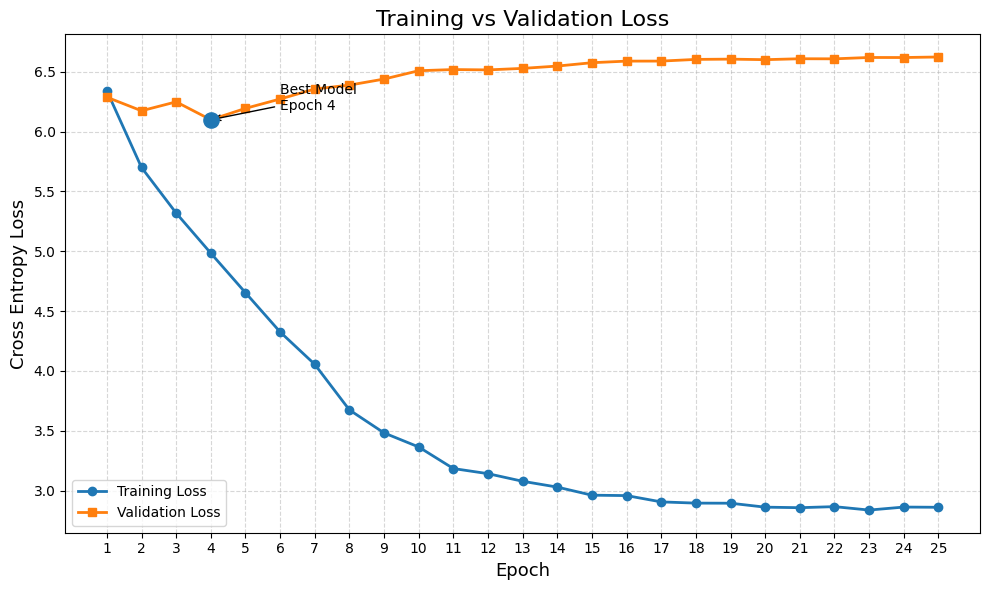

In [ ]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 26))

# Training Loss
train_loss = [
    6.3409, 5.7005, 5.3194, 4.9841, 4.6538,
    4.3256, 4.0547, 3.6737, 3.4816, 3.3640,
    3.1837, 3.1409, 3.0772, 3.0286, 2.9610,
    2.9576, 2.9049, 2.8947, 2.8939, 2.8609,
    2.8565, 2.8653, 2.8366, 2.8617, 2.8599
]

# Validation Loss
valid_loss = [
    6.2877, 6.1743, 6.2489, 6.0993, 6.1944,
    6.2727, 6.3563, 6.3889, 6.4395, 6.5092,
    6.5190, 6.5161, 6.5287, 6.5481, 6.5761,
    6.5895, 6.5897, 6.6038, 6.6061, 6.6015,
    6.6093, 6.6086, 6.6199, 6.6195, 6.6240
]

plt.figure(figsize=(10,6))

plt.plot(epochs, train_loss,
         marker='o',
         linewidth=2,
         label='Training Loss')

plt.plot(epochs, valid_loss,
         marker='s',
         linewidth=2,
         label='Validation Loss')

# Highlight best validation loss
best_epoch = 4
best_loss = 6.0993

plt.scatter(best_epoch, best_loss, s=120, zorder=5)
plt.annotate(f'Best Model\nEpoch {best_epoch}',
             xy=(best_epoch, best_loss),
             xytext=(6, 6.18),
             arrowprops=dict(arrowstyle='->'))

plt.title("Training vs Validation Loss", fontsize=16)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Cross Entropy Loss", fontsize=13)

plt.xticks(range(1,26))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig("training_validation_loss.png", dpi=300, bbox_inches='tight')

plt.show()